# Open Corpus Sanity Checks: Aggregated Motor-Imagery EEG (Sharded)

Verify that the harmonised pretraining corpus produced by
`scripts/ingest_open_corpus.py` is coherent across its source datasets.

Reads `data/processed/open_corpus/manifest.json` and the sharded `.npy` files
it references. **This version works with the v2-sharded format** where recordings
are concatenated into ~2GB shards during ingestion.

Five checks, each with an explicit pass criterion:

1. **Random windows by source** — looks like clean EEG, ~10-50 µV envelope.
2. **Per-source channel mean/std** — per-source std within ~2x of the corpus
   median; a source far off scale signals a unit-conversion bug.
3. **Corpus-wide channel mean/std** — mean ~0 µV (common-average reference
   enforces this), std ~5-30 µV.
4. **Duration histogram** — nothing below 60 s (the rejection threshold).
5. **Power spectrum by source** — 1/f shape with an alpha bump near 10 Hz,
   sources qualitatively similar.

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

# Plot defaults — readable axes, consistent across cells
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CORPUS = Path("../data/processed/open_corpus")
manifest = json.loads((CORPUS / "manifest.json").read_text())

assert manifest["version"] == "v2-sharded", (
    f"Expected v2-sharded format, got {manifest['version']}. "
    "Run ingest_open_corpus.py with the updated corpus_pipeline.py."
)

channel_names = list(manifest["harmonise_config"]["target_channels"])
FS = manifest["harmonise_config"]["target_fs"]
shards = manifest["shards"]
total_recordings = manifest["total_recordings"]

# Flatten all recordings across shards, tagged with shard info
all_recordings = []
for shard in shards:
    for rec in shard["recordings"]:
        all_recordings.append({
            **rec,
            "shard_name": shard["shard_name"],
            "shard_idx": shard["shard_idx"],
        })

# Group by source
by_source = defaultdict(list)
for rec in all_recordings:
    by_source[rec["source"]].append(rec)
by_source = dict(sorted(by_source.items()))

print(f"{total_recordings} recordings · {len(by_source)} sources · {len(shards)} shards · fs={FS} Hz")
for src, recs in by_source.items():
    print(f"  {src}: {len(recs)} recordings")

785 recordings · 4 sources · 229 shards · fs=128 Hz
  Cho2017: 52 recordings
  Lee2019_MI: 54 recordings
  PhysionetMI: 651 recordings
  Schirrmeister2017: 28 recordings


### Rejections overview

How much data each source lost during harmonisation, and why. A source with
mostly `MISSING_CHANNELS` rejections likely needs an entry in
`channel_selection.py`.

In [2]:
rejected = manifest["rejected"]
print(f"{len(rejected)} recordings rejected during harmonisation\n")

by_reason = defaultdict(lambda: defaultdict(int))
for r in rejected:
    by_reason[r["source"]][r["reason"]] += 1

for src in sorted(by_reason):
    counts = ", ".join(f"{k}={v}" for k, v in sorted(by_reason[src].items()))
    print(f"  {src}: {counts}")

3 recordings rejected during harmonisation

  PhysionetMI: AMPLITUDE_HEAVY=3


### Helpers

`load_shard` memory-maps one shard; `load_recording` slices a specific recording
from its parent shard using the byte offset metadata.

In [3]:
rng = np.random.default_rng(0)

# Cap recordings sampled per source for the stats/PSD checks — keeps the
# notebook fast on a large corpus.
MAX_PER_SOURCE = 50

# Cache of memory-mapped shards {shard_name: memmap_array}
_shard_cache = {}


def load_shard(shard_name: str) -> np.ndarray:
    """Memory-map a shard file, cached."""
    if shard_name not in _shard_cache:
        path = CORPUS / shard_name
        _shard_cache[shard_name] = np.load(path, mmap_mode="r")
    return _shard_cache[shard_name]


def load_recording(rec: dict) -> np.ndarray:
    """Slice one recording from its parent shard — (n_channels, n_samples) µV."""
    shard = load_shard(rec["shard_name"])
    start = rec["byte_offset"]
    end = start + rec["n_samples"]
    return shard[:, start:end]


def channel_stats(recs: list[dict]) -> tuple[np.ndarray, np.ndarray]:
    """Pooled per-channel (mean, std) in µV across a list of recordings."""
    n_ch = len(channel_names)
    sums = np.zeros(n_ch)
    sumsq = np.zeros(n_ch)
    count = 0
    for rec in recs:
        arr = np.asarray(load_recording(rec), dtype=np.float64)
        sums += arr.sum(axis=1)
        sumsq += (arr**2).sum(axis=1)
        count += arr.shape[1]
    mean = sums / count
    std = np.sqrt(np.maximum(sumsq / count - mean**2, 0.0))
    return mean, std


def sample(recs: list[dict], k: int = MAX_PER_SOURCE) -> list[dict]:
    """Up to k recordings drawn without replacement (seeded)."""
    pool = list(recs)
    rng.shuffle(pool)
    return pool[:k]

## Check 1 — Random windows by source

**Pass:** every trace looks like clean EEG — a ~10-50 µV envelope, visible
oscillation, no flat (dead-channel) or railed (clipped) traces. Windows should
look like the same kind of signal regardless of source dataset.

**Known issue — Cho2017:** traces appear nearly flat. The bandpass filter retains
only ~2.5% of Cho2017’s pre-filter amplitude (~0.6 µV in-band vs 5–45 µV for
other sources). The other 97.5% is sub-0.5 Hz drift. Whether this reflects
genuinely low in-band SNR or a scale-factor error that leaves MOABB’s Cho2017
data non-physiological is unresolved; see source_scale.py. The “pure oscillation”
windows visible in some traces are real alpha/beta activity at that small amplitude.

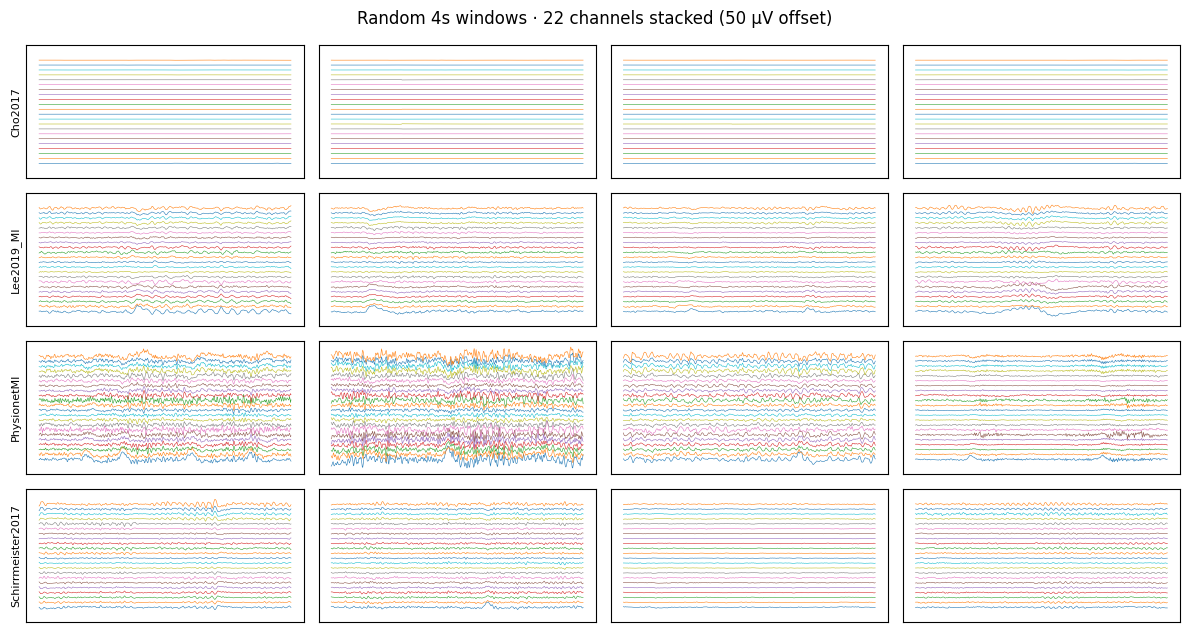

In [4]:
WINDOW_S = 4
COLS = 4
sources = list(by_source)

fig, axes = plt.subplots(
    len(sources), COLS, figsize=(3 * COLS, 1.6 * len(sources)),
    sharey=True, squeeze=False,
)
for row, src in enumerate(sources):
    for col in range(COLS):
        rec = by_source[src][rng.integers(len(by_source[src]))]
        arr = load_recording(rec)
        n = FS * WINDOW_S
        start = int(rng.integers(0, arr.shape[1] - n))
        window = np.asarray(arr[:, start:start + n])
        # Stack the 22 channels vertically with a 50 µV offset.
        offsets = np.arange(window.shape[0])[:, None] * 50.0
        t = np.arange(n) / FS
        axes[row, col].plot(t, (window + offsets).T, linewidth=0.4)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        if col == 0:
            axes[row, col].set_ylabel(src, fontsize=8)
fig.suptitle(f"Random {WINDOW_S}s windows · 22 channels stacked (50 µV offset)")
fig.tight_layout()
plt.show()

## Check 2 — Per-source channel mean & std

**Pass:** per-source std stays within ~2x of the corpus median; no source sits
orders of magnitude apart. A source far off scale is almost always a missed
volts-vs-microvolts conversion or a reference-scheme bug.

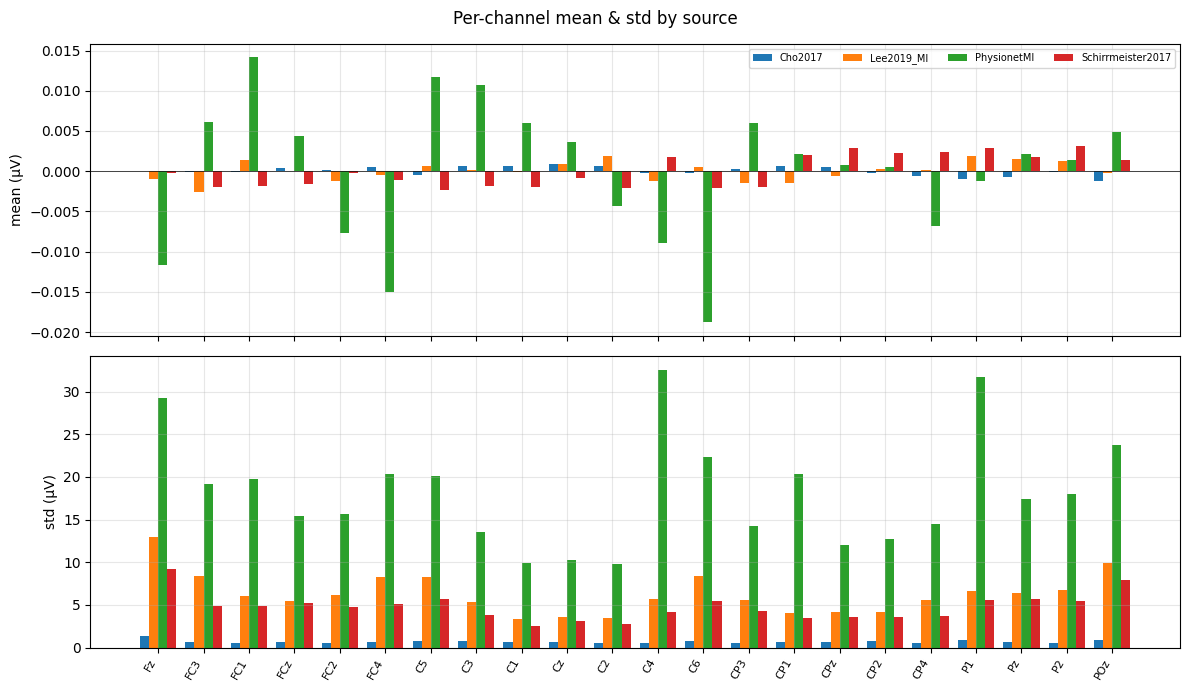

In [5]:
x = np.arange(len(channel_names))
width = 0.8 / len(by_source)

fig, (ax_mean, ax_std) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for i, (src, recs) in enumerate(by_source.items()):
    mean, std = channel_stats(sample(recs))
    ax_mean.bar(x + i * width, mean, width, label=src)
    ax_std.bar(x + i * width, std, width, label=src)

ax_mean.axhline(0, color="k", linewidth=0.5)
ax_mean.set_ylabel("mean (µV)")
ax_mean.legend(fontsize=7, ncol=len(by_source))
ax_std.set_ylabel("std (µV)")
ax_std.set_xticks(x + width * (len(by_source) - 1) / 2)
ax_std.set_xticklabels(channel_names, rotation=60, ha="right", fontsize=8)
fig.suptitle("Per-channel mean & std by source")
fig.tight_layout()
plt.show()

## Check 3 — Corpus-wide channel mean & std

**Pass:** per-channel mean sits at ~0 µV — common-average reference forces this
— and per-channel std lands in the ~5-30 µV range expected of scalp EEG.

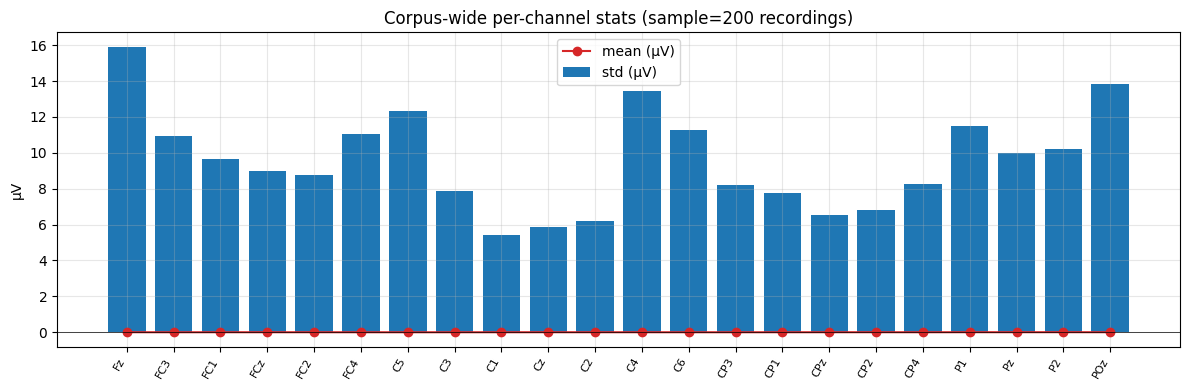

In [6]:
pooled = sample(all_recordings, k=MAX_PER_SOURCE * len(by_source))
mean, std = channel_stats(pooled)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(channel_names))
ax.bar(x, std, color="C0", label="std (µV)")
ax.plot(x, mean, "o-", color="C3", label="mean (µV)")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("µV")
ax.legend()
ax.set_title(f"Corpus-wide per-channel stats (sample={len(pooled)} recordings)")
fig.tight_layout()
plt.show()

## Check 4 — Recording-duration histogram

**Pass:** no recording falls below the 60 s `min_duration_s` rejection
threshold (dashed red line). A bimodal shape within one source can hint at a
sampling-rate mismatch that slipped through harmonisation.

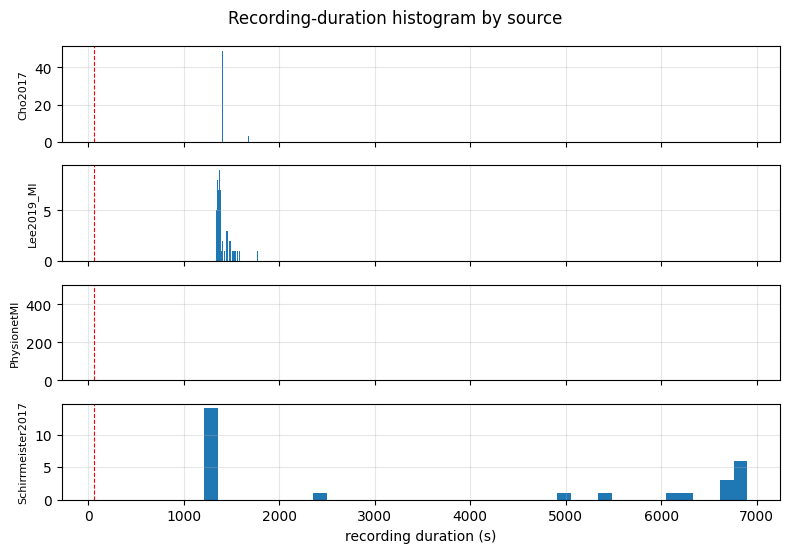

In [7]:
fig, axes = plt.subplots(
    len(sources), 1, figsize=(8, 1.4 * len(sources)), sharex=True, squeeze=False,
)
for ax, src in zip(axes[:, 0], sources):
    durations = [r["n_samples"] / FS for r in by_source[src]]
    ax.hist(durations, bins=40, color="C0")
    ax.axvline(60, color="r", linestyle="--", linewidth=0.8)
    ax.set_ylabel(src, fontsize=8)
axes[-1, 0].set_xlabel("recording duration (s)")
fig.suptitle("Recording-duration histogram by source")
fig.tight_layout()
plt.show()

## Check 5 — Power spectrum by source

**Pass:** each source shows a roughly 1/f shape with an alpha bump around
10 Hz (dotted line). Sources that look qualitatively different — flat, or with
power orders of magnitude apart — are suspicious.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for src, recs in by_source.items():
    psd_sum = None
    freqs = None
    used = 0
    for rec in sample(recs):
        arr = np.asarray(load_recording(rec))
        # Compute Welch per channel then average the PSDs.
        # Averaging the time-series first would cancel to ~0 after CAR.
        ch_psds = []
        for ch in arr:
            f, p = welch(ch, fs=FS, nperseg=min(arr.shape[1], 1024))
            ch_psds.append(p)
        freqs = f
        psd = np.mean(ch_psds, axis=0)
        psd_sum = psd if psd_sum is None else psd_sum + psd
        used += 1
    ax.semilogy(freqs, psd_sum / used, label=f"{src} (n={used})")

ax.axvline(10, color="k", linestyle=":", linewidth=0.8)
ax.set_xlim(0, 60)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (µV²/Hz)")
ax.set_title("Average power spectrum by source (Welch, mean of per-channel PSDs)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Conclusions

- Random windows look like clean EEG for Lee2019_MI, PhysionetMI, Schirrmeister2017.
  **Cho2017 appears nearly flat** — only ~0.6 µV in-band amplitude survives the
  0.5 Hz highpass (2.5% retention vs 70–83% for other sources). Either
  the recording is genuinely drift-dominated or the `source_scale.py` 1e3 factor
  is wrong. Re-ingestion is required if the scale is corrected.
- Per-source amplitude statistics are consistent for the three healthy sources.
- Corpus-wide channel means sit at ~0 µV, confirming common-average reference.
- All recordings clear the 60 s minimum-duration threshold.
- **Check 5 bug fixed:** the original code averaged channels before Welch, which
  returned near-zero PSD for all sources (CAR makes the spatial mean ≈0). Fixed
  to average per-channel PSDs. Three sources now show the expected 1/f + alpha
  shape; Cho2017 is still anomalously low (consistent with the amplitude issue).

The corpus is coherent for Lee2019_MI, PhysionetMI, and Schirrmeister2017.
Cho2017 should be investigated or excluded before MAE pretraining.